In [1]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
warnings.filterwarnings("ignore")

## Load the Dataset

In [2]:
file = "/home/shanujya/BITS_MSC/Feature Engineering/Financial Risk Prediction/Synthetic_Loan_Dataset.xlsx"
df = pd.read_excel(file)
print("Succesfully load the datset")

Succesfully load the datset


In [3]:
# Preview the dataset
df.head()

,age,income,credit_score,loan_amount,monthly_spend,experience_years,employment_type,education_level,region,risk_tolerance,financial_capacity_index,household_cashflow_score,behavior_score,loan_default
0,43.960570,31019.390823,650.336822,33805.550343,1732.298149,13,salaried,bachelor,east,high,31.019391,38.732577,38.393095,0
1,36.340828,39375.961557,648.261012,20974.755713,2334.610693,32,salaried,bachelor,north,high,39.375962,45.595276,62.162754,0
2,45.772262,18055.668704,554.304978,26027.339787,1848.435993,1,salaried,bachelor,south,low,18.055669,15.033732,51.200728,1
3,56.276358,15254.929250,656.893687,20798.610521,3256.259548,1,unemployed,master,east,low,15.254929,25.533778,73.122834,0
4,35.190160,11486.292927,731.298036,14661.332950,7767.804367,30,salaried,master,west,low,11.486293,6.237571,52.571462,0


In [4]:
# Check dimension of the dataset
df.shape

(2500, 14)

##  Dataset Understanding and Exploratory Data Analysis (EDA)

### Looking for more information about data

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2375 non-null   float64
 1   income                    2500 non-null   float64
 2   credit_score              2300 non-null   float64
 3   loan_amount               2500 non-null   float64
 4   monthly_spend             2500 non-null   float64
 5   experience_years          2500 non-null   int64  
 6   employment_type           2375 non-null   str    
 7   education_level           2500 non-null   str    
 8   region                    2500 non-null   str    
 9   risk_tolerance            2500 non-null   str    
 10  financial_capacity_index  2500 non-null   float64
 11  household_cashflow_score  2500 non-null   float64
 12  behavior_score            2500 non-null   float64
 13  loan_default              2500 non-null   int64  
dtypes: float64(8), int6

In our dataset, there are 10 numerical variables and 4 categorical variables.

In [6]:
# Check all Features Names
df.columns

Index(['age', 'income', 'credit_score', 'loan_amount', 'monthly_spend',
       'experience_years', 'employment_type', 'education_level', 'region',
       'risk_tolerance', 'financial_capacity_index',
       'household_cashflow_score', 'behavior_score', 'loan_default'],
      dtype='str')

In [7]:
# Categorical Features in the dataset
categorical_cols = df.select_dtypes(include=['str']).columns.tolist()
print(categorical_cols)

['employment_type', 'education_level', 'region', 'risk_tolerance']


In [8]:
# Numerical Features in the dataset
numerical_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
print(numerical_cols)

['age', 'income', 'credit_score', 'loan_amount', 'monthly_spend', 'experience_years', 'financial_capacity_index', 'household_cashflow_score', 'behavior_score', 'loan_default']


In [9]:
# Select Key numeric Columns
key_numeric = ['age','income','credit_score','loan_amount','monthly_spend']
print(key_numeric)

['age', 'income', 'credit_score', 'loan_amount', 'monthly_spend']


The reason i have chose this as key numeric features is that in the banking and credit industry these five variables are universally considered the most fondational factors in determining the loan risk.

In [10]:
# Check descriptive statistics for the data.
df.describe()

,age,income,credit_score,loan_amount,monthly_spend,experience_years,financial_capacity_index,household_cashflow_score,behavior_score,loan_default
count,2375.000000,2500.000000,2300.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,38.617037,26864.999724,677.513832,20102.542603,4013.070946,17.124000,26.071650,26.697079,50.014697,0.186000
std,11.375320,20091.626397,71.032915,7890.874475,3663.282652,10.101477,17.361648,18.272229,9.905279,0.389185
min,18.000000,3274.687462,454.528855,1000.000000,200.244019,0.000000,3.274687,-9.138941,13.923345,0.000000
25%,30.462617,14411.106577,629.316557,14771.636109,1755.975077,9.000000,14.390371,15.069634,43.327227,0.000000
50%,38.344938,22052.298380,677.143115,20089.633564,2926.958460,17.000000,21.926530,23.135050,50.013543,0.000000
75%,46.184030,32894.193900,726.449956,25374.566413,4986.269855,26.000000,32.486876,34.008478,56.435018,0.000000
max,75.000000,265497.957871,850.000000,47019.063353,44454.194148,34.000000,232.290175,233.565716,83.891124,1.000000


In [11]:
df['loan_default'].value_counts()

loan_default
0    2035
1     465
Name: count, dtype: int64

Loan Defaulted : 1 = 465 and 
Not Defaulted : 0 = 2035

In [12]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [13]:
# Checking the missing values in the dataset
df.isnull().sum()

age                         125
income                        0
credit_score                200
loan_amount                   0
monthly_spend                 0
experience_years              0
employment_type             125
education_level               0
region                        0
risk_tolerance                0
financial_capacity_index      0
household_cashflow_score      0
behavior_score                0
loan_default                  0
dtype: int64

age,credit_score and employment_type have null values which need to be handle

## Some characteristic of Data & Visualization

### Distribution plots for key numeric features

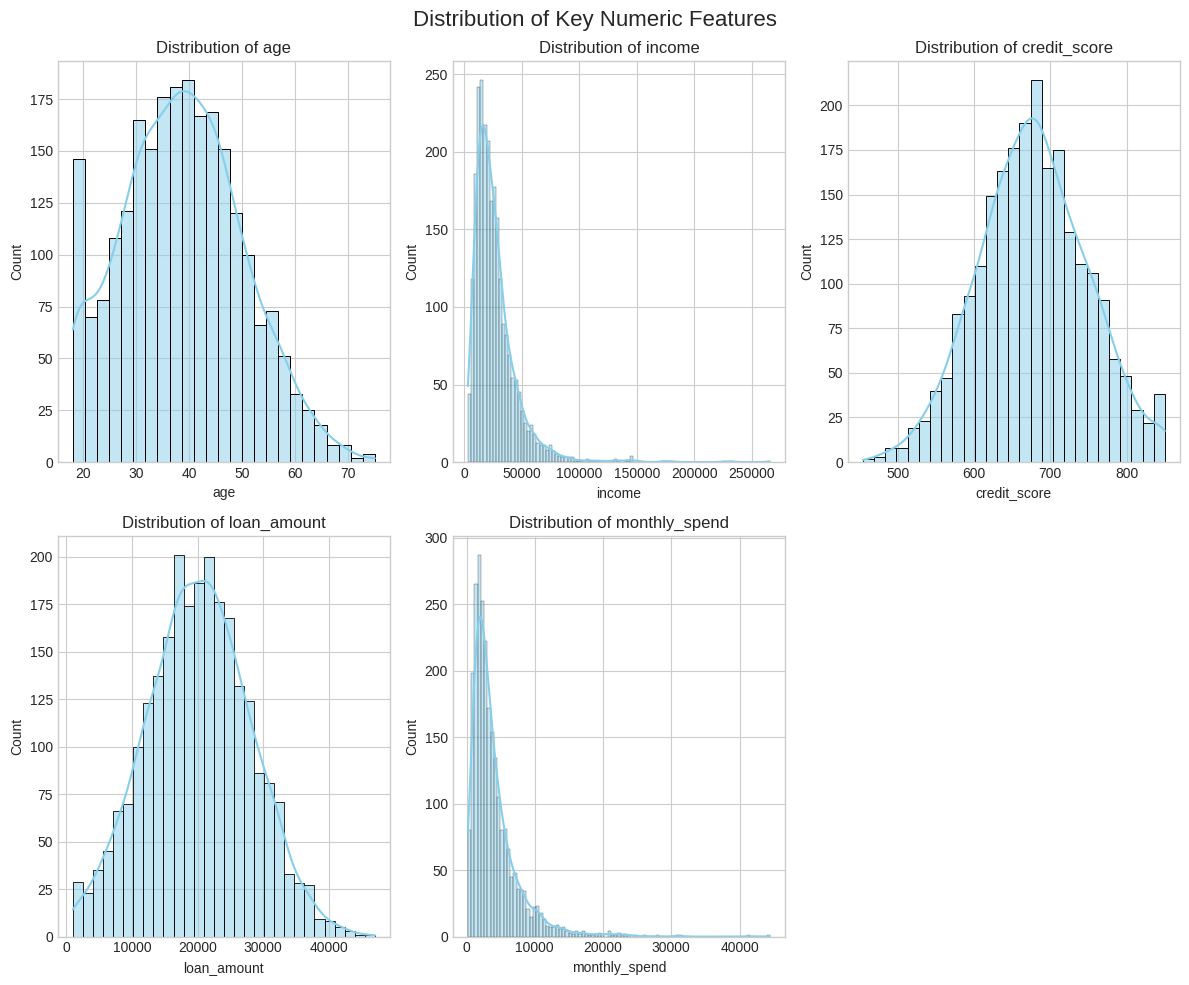

In [14]:
fig,axes = plt.subplots(2,3,figsize=(12,10))

for i, col in enumerate(key_numeric):
    sns.histplot(df[col], kde=True, ax=axes[i//3, i%3], color='skyblue')
    axes[i//3, i%3].set_title(f'Distribution of {col}')
    
# Remove the empty 6th subplot (row 1, col 2) so it doesn't show a blank box
axes[1,2].remove()
    
plt.suptitle("Distribution of Key Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

Interpretation:-

1. Normal Distribution(Bell Curve): Features such as Age,Credit Score and Loan Amount exhibit a relatively symmetrical,normal distribution.This indicates that most customer fall into an average middle range, with fewer customers at the extreme high or low ends.


2. Right Skewed Distribution: Both Income and Monthly Spend are heavily skewed to the right.Majority of the customers have lower to moderate income and spending habit, there is a long tail of outliers representing small number of people with exceptionally high income and spending.

This issue will need to address further in data cleaning step.

### Missing values visualization

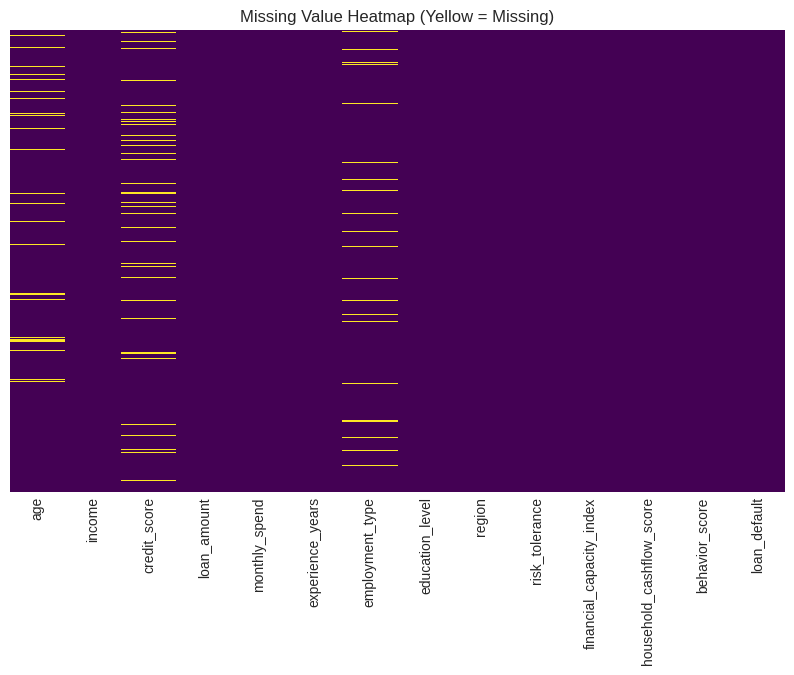

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Missing Value Heatmap (Yellow = Missing)')
plt.show()

Interpretation:-

The missing value heatmap and summary statistic reveal null values in three features: Age(125 missing),credit score(200 missing) and categorical feature employment_type(125 missing) because the dataset is small(2500 Rows) dropping them would be the significant loss of the data.


In Data cleaning step imputation strategy will be required.

### Correlation heatmap for numeric features

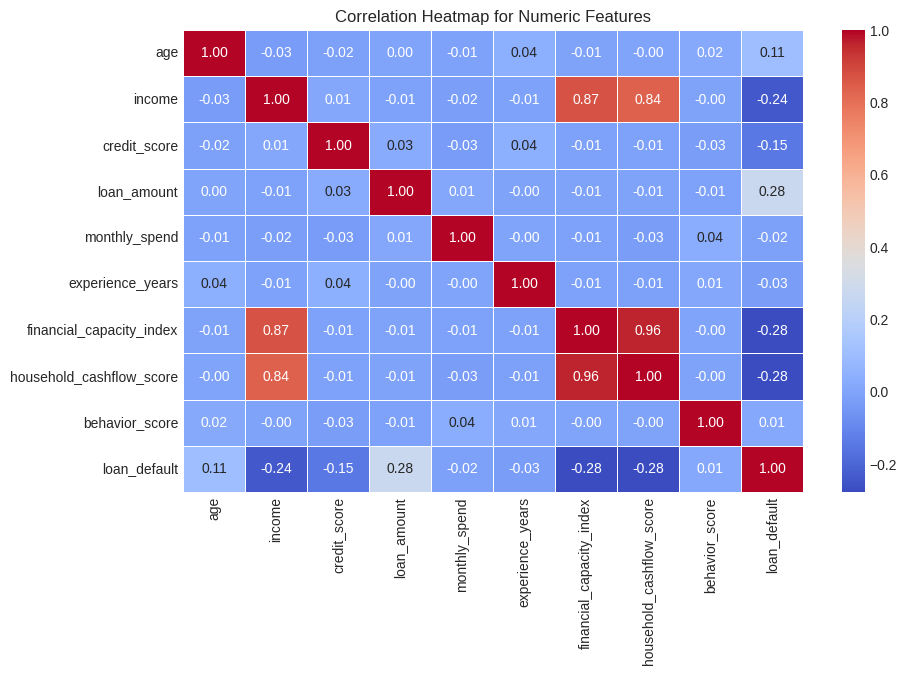

In [16]:
plt.figure(figsize=(10,6))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f",linewidth=0.5)
plt.title("Correlation Heatmap for Numeric Features")
plt.show()

Interpretation:-

* The Correlation heatmap reveals a crtitcal data issue: Multicollinearity.
* financial_capacity_index and household_cashflow_score have an extremely high positive correlation (0.96). Both of these features also show a high correlation with income feature(~0.84 to 0.87) as well.This suggests these scores are highly redundant and capturing the exact same underlying information.Retaining both could destabilize certain ML model.so we need to drop or combine them later.

### Boxplots showing categorical features vs loan_default



Note:- Because boxplots require a continuous variable, I have visualized the true Categorical vs. Target relationships using countplots, and provided Boxplots to show the Numeric vs. Target relationships.

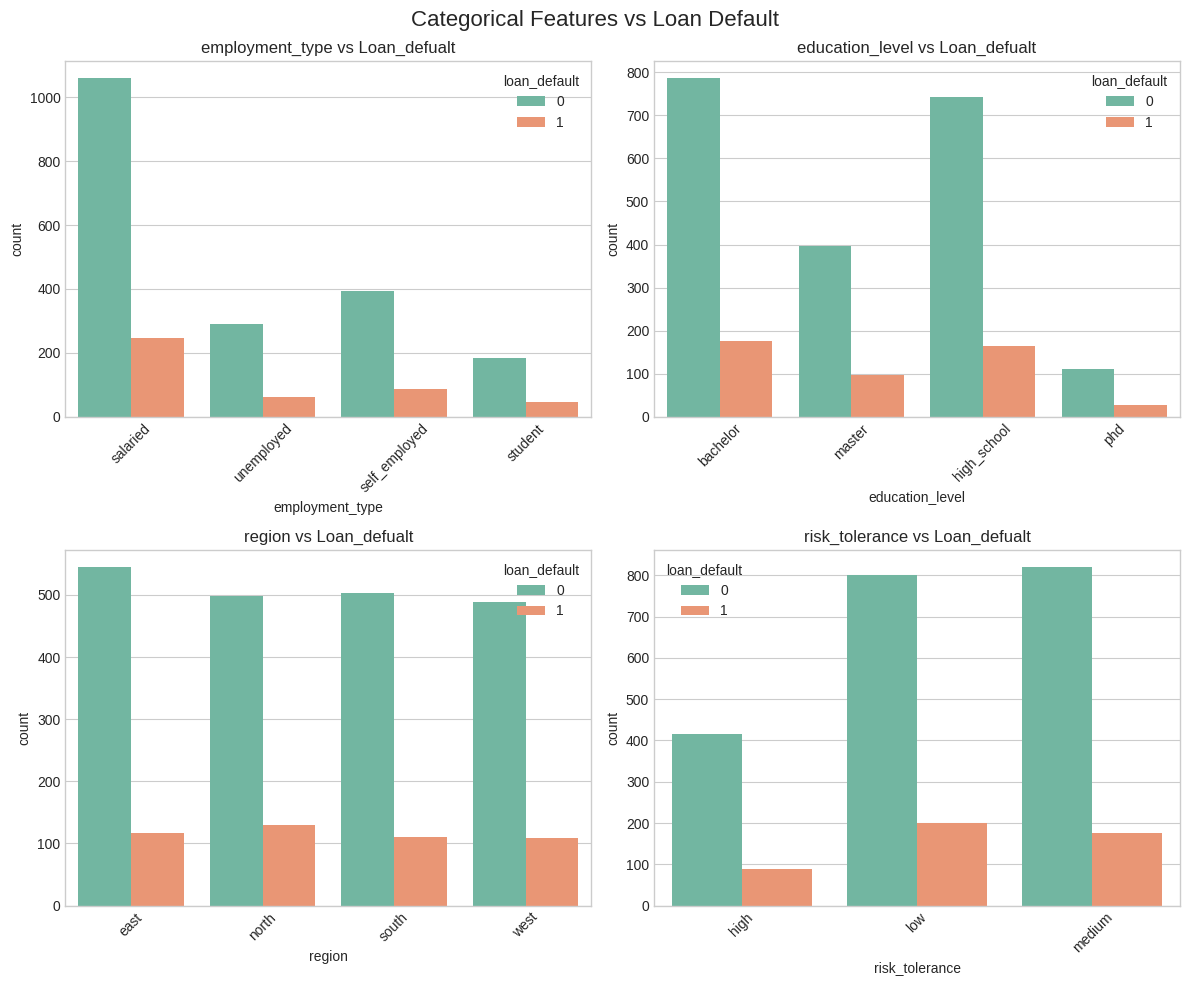

In [17]:
fig,axes = plt.subplots(2,2,figsize=(12,10))

for i,col in enumerate(categorical_cols):
    sns.countplot(data=df,x=col,hue='loan_default',ax=axes[i//2,i%2],palette='Set2')
    axes[i//2,i%2].set_title(f"{col} vs Loan_defualt")
    axes[i//2,i%2].tick_params(axis='x', rotation=45)

plt.suptitle("Categorical Features vs Loan Default", fontsize=16)
plt.tight_layout()
plt.show()

Interpretation:-

By observing the categorical variable split with the target variable(loan_default), we can see if certain demographic or employment profiles are disproportionately represents in the default category.For example risk tolerance or employment_type may serve as strong discriminator between safe and risky borrowers.

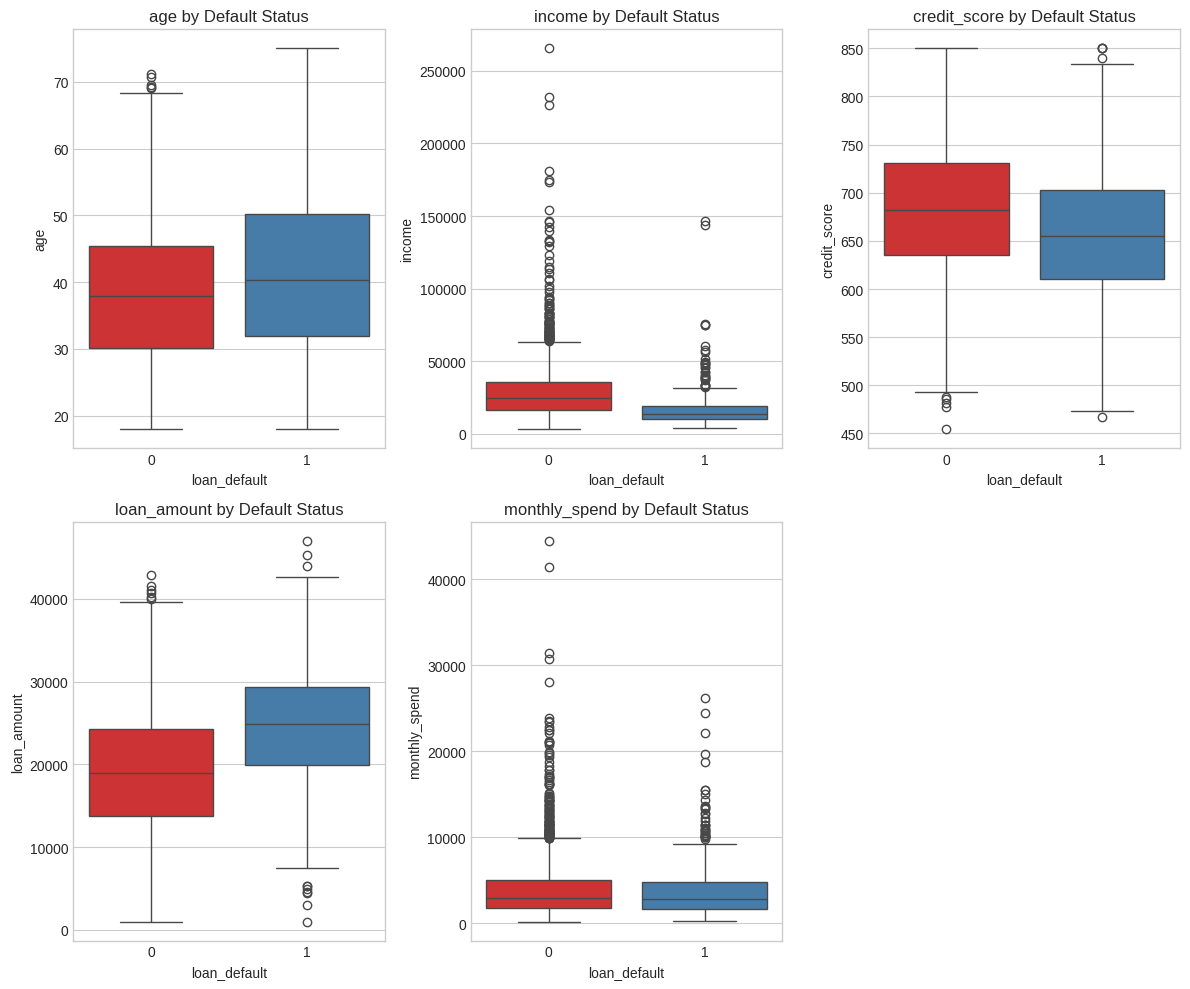

In [18]:
fig,axes = plt.subplots(2,3,figsize=(12,10))

for i, col in enumerate(key_numeric):
    sns.boxplot(data=df,x='loan_default',y=col,ax=axes[i//3,i%3],palette="Set1")
    axes[i//3, i%3].set_title(f'{col} by Default Status')
    
# Remove the empty 6th subplot (row 1, col 2) so it doesn't show a blank box
axes[1,2].remove()

plt.tight_layout()
plt.show()

## Data Cleaning

In [19]:
print("Missing values BEFORE cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])

Missing values BEFORE cleaning:
 age                125
credit_score       200
employment_type    125
dtype: int64


In [20]:
# Test for missing data mechanism
print("\n---Testing Missing Data Mechanism---")

# Create a binary indicators (1:if missing,0:if present)
df['age_missing'] = df['age'].isnull().astype(int)
df['credit_missing'] = df['credit_score'].isnull().astype(int)

# Check how missingness correlates with the other numeric variables
numeric_cols = df.select_dtypes(include=[np.number]).columns
missing_corr = df[numeric_cols].corr()[['age_missing', 'credit_missing']].drop(['age_missing', 'credit_missing'])

print("\nCorrelation of missing data with other features:\n")
print(missing_corr.round(3))

print("\nConclusion: The correlations are extremely close to 0.00. This proves the data is")
print("Missing Completely At Random (MCAR). Therefore, median/mode imputation is mathematically safe.\n")

# Drop the temporary indicator columns since we don't need them anymore
df = df.drop(columns=['age_missing', 'credit_missing'])


---Testing Missing Data Mechanism---

Correlation of missing data with other features:

                          age_missing  credit_missing
age                               NaN          -0.020
income                         -0.000          -0.027
credit_score                   -0.010             NaN
loan_amount                     0.020           0.003
monthly_spend                   0.058           0.006
experience_years               -0.019          -0.007
financial_capacity_index       -0.001          -0.017
household_cashflow_score        0.003          -0.015
behavior_score                 -0.010           0.034
loan_default                    0.018           0.022

Conclusion: The correlations are extremely close to 0.00. This proves the data is
Missing Completely At Random (MCAR). Therefore, median/mode imputation is mathematically safe.



### Handling Missing Values

In [21]:
# Impute Numeric Feature with the median
df['age'] = df['age'].fillna(df['age'].median())
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())

# Impute categorical feature with the mode
df['employment_type'] = df['employment_type'].fillna(df['employment_type'].mode()[0])

print("Missing values After cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])

Missing values After cleaning:
 Series([], dtype: int64)


Interpretation:

* **Problem Identified:** Missing data in age (125 rows), credit_score (200 rows), and employment_type (125 rows).

* **Method Used:** After checking how missingness correlates with other numeric variables and came to conclusion that the data is missing at complete random(MCAR).Therefore i used median for impute numerical variable and mode for categorical variable.

* **Why the chosen method appropriate:** 
     * Statistical Proof(MCAR): A Correlation analysis showed the missing value have near zero correlation with other numerical variables.This proves the data is missing at complete random.Because the missingness is purely random, imputation is mathematically safe and will not introduce systematic bias.
     
     * Numeric Features(Median): Missing values in age and credit score filled with median.Unlike the mean,median is robust against extreme outliers and ensuring the normal distribution of these features would be preserved.
     
     * categorical features(Mode): employment_type was filled using the mode (most frequent value).

In [22]:
df.isnull().sum()

age                         0
income                      0
credit_score                0
loan_amount                 0
monthly_spend               0
experience_years            0
employment_type             0
education_level             0
region                      0
risk_tolerance              0
financial_capacity_index    0
household_cashflow_score    0
behavior_score              0
loan_default                0
dtype: int64

### Handling Extreme Values (Outliers)

In [23]:
income_99th = df['income'].quantile(0.99)
spend_99th = df['monthly_spend'].quantile(0.99)

df['income'] = df['income'].clip(upper=income_99th)
df['monthly_spend'] = df['monthly_spend'].clip(upper=spend_99th)

print(f"Max income after capping: ${df['income'].max():.2f}")
print(f"Max Monthly Spend after capping: ${df['monthly_spend'].max():.2f}")

Max income after capping: $99425.23
Max Monthly Spend after capping: $18799.65


Interpretation:

* **Problem Identified:** As seen in EDA distribution plot, income and monthly_spend are heavily right skewed with extreme values(e.g., maximum income was over 265,000 dollars compared to a mean of 26,000 dollars).

* **Method Used:** **Winsorization (Capping)** at the 99th percentile. Any value above the 99th percentile was replaced with the exact value of the 99th percentile.

* **Why the chosen method appropriate:** Removing these entire outliers row would delete valid,wealthy customers from our dataset. By capping them instead making dataset more robust for modelling.

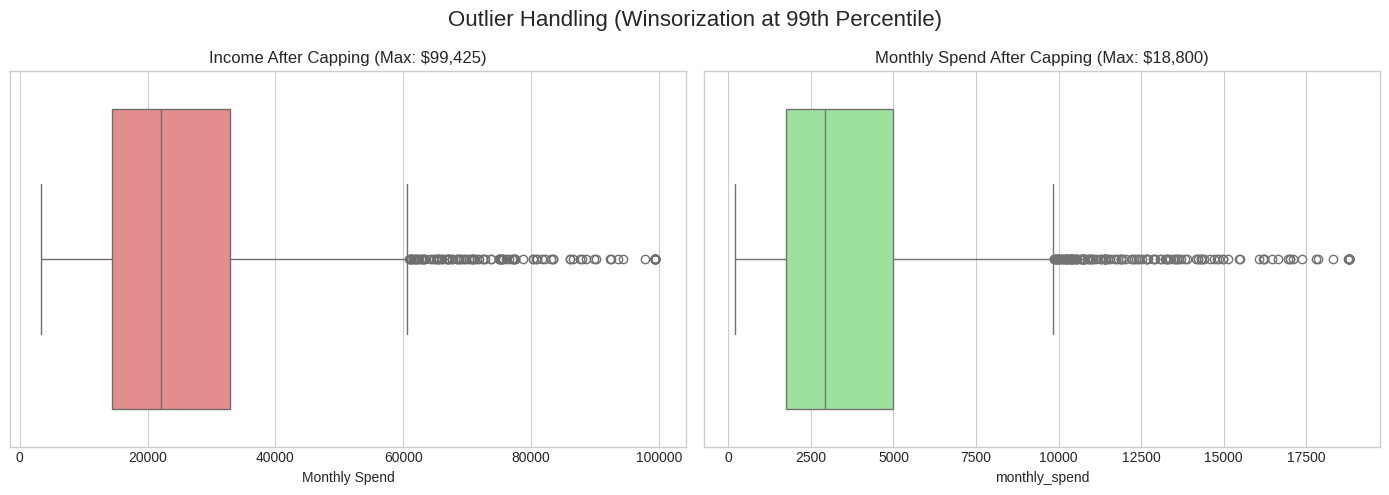

In [24]:
# Visual proof of Outlier handling
fig,axes = plt.subplots(1,2,figsize=(14,5))

sns.boxplot(data=df,x='income',ax=axes[0],color='lightcoral')
axes[0].set_title(f"Income After Capping (Max: ${df['income'].max():,.0f})")
axes[0].set_xlabel("Income")

sns.boxplot(data=df,x='monthly_spend',ax=axes[1],color='lightgreen')
axes[1].set_title(f"Monthly Spend After Capping (Max: ${df['monthly_spend'].max():,.0f})")
axes[0].set_xlabel("Monthly Spend")

plt.suptitle("Outlier Handling (Winsorization at 99th Percentile)", fontsize=16)
plt.tight_layout()
plt.show()

In [25]:
# After capping descriptive statistics of Data
df.describe()

,age,income,credit_score,loan_amount,monthly_spend,experience_years,financial_capacity_index,household_cashflow_score,behavior_score,loan_default
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,38.603433,26380.686413,677.484175,20102.542603,3956.024141,17.124000,26.071650,26.697079,50.014697,0.186000
std,11.087333,17119.727701,68.131267,7890.874475,3317.740897,10.101477,17.361648,18.272229,9.905279,0.389185
min,18.000000,3274.687462,454.528855,1000.000000,200.244019,0.000000,3.274687,-9.138941,13.923345,0.000000
25%,30.846518,14411.106577,634.808252,14771.636109,1755.975077,9.000000,14.390371,15.069634,43.327227,0.000000
50%,38.344938,22052.298380,677.143115,20089.633564,2926.958460,17.000000,21.926530,23.135050,50.013543,0.000000
75%,45.767829,32894.193900,719.199289,25374.566413,4986.269855,26.000000,32.486876,34.008478,56.435018,0.000000
max,75.000000,99425.228474,850.000000,47019.063353,18799.654138,34.000000,232.290175,233.565716,83.891124,1.000000


## Numeric Feature Engineering

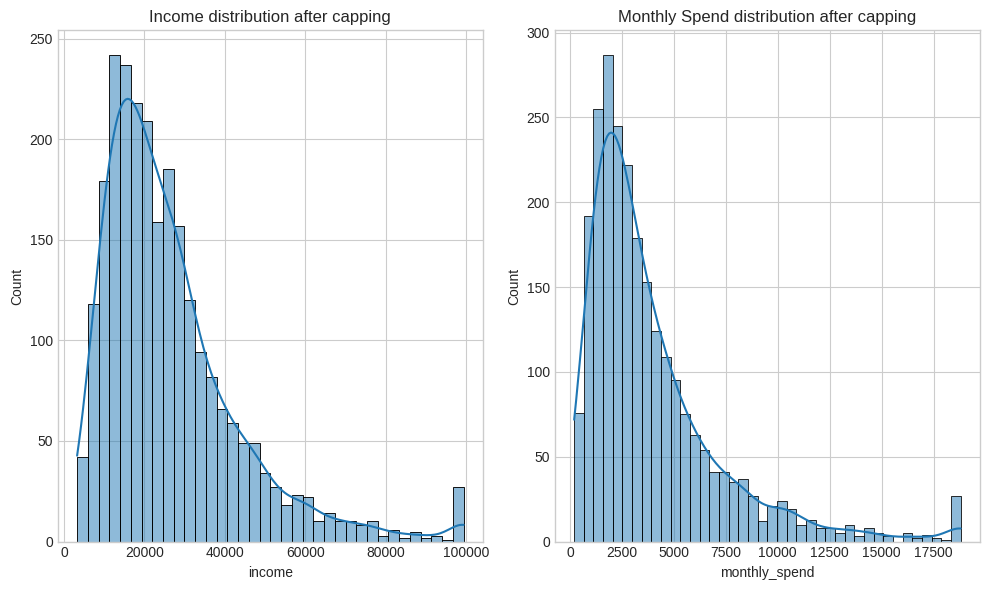

In [26]:
# I want to first check the distribution for income and monthly_spend variables after capping.
fig,axes = plt.subplots(1,2,figsize=(10,6))

sns.histplot(df['income'],kde=True,ax=axes[0])
axes[0].set_title('Income distribution after capping')

sns.histplot(df['monthly_spend'],kde=True,ax=axes[1])
axes[1].set_title('Monthly Spend distribution after capping')

plt.tight_layout()
plt.show()

After capping, the extreme values are reduced but income and monthly_spend remain heavily right-skewed.This indicates that outliers were controlled, but the overall distribution shape is still uneven.This situation motivates me to applying **log transformation** for handling the skewness.

### Log Transformation

In [27]:
# log transformation applied on income and monthly_spend
df['income_log'] = np.log1p(df['income'])
df['spend_log'] = np.log1p(df['monthly_spend'])

print("Log transformation applied to 'income' -> created 'income_log'")
print("Log transformation applied to 'monthly_spend' -> created 'spend_log'")

Log transformation applied to 'income' -> created 'income_log'
Log transformation applied to 'monthly_spend' -> created 'spend_log'


In [28]:
df[['income', 'income_log']].describe()

,income,income_log
count,2500.000000,2500.000000
mean,26380.686413,9.995750
std,17119.727701,0.612213
min,3274.687462,8.094283
25%,14411.106577,9.575824
50%,22052.298380,10.001217
75%,32894.193900,10.401082
max,99425.228474,11.507171


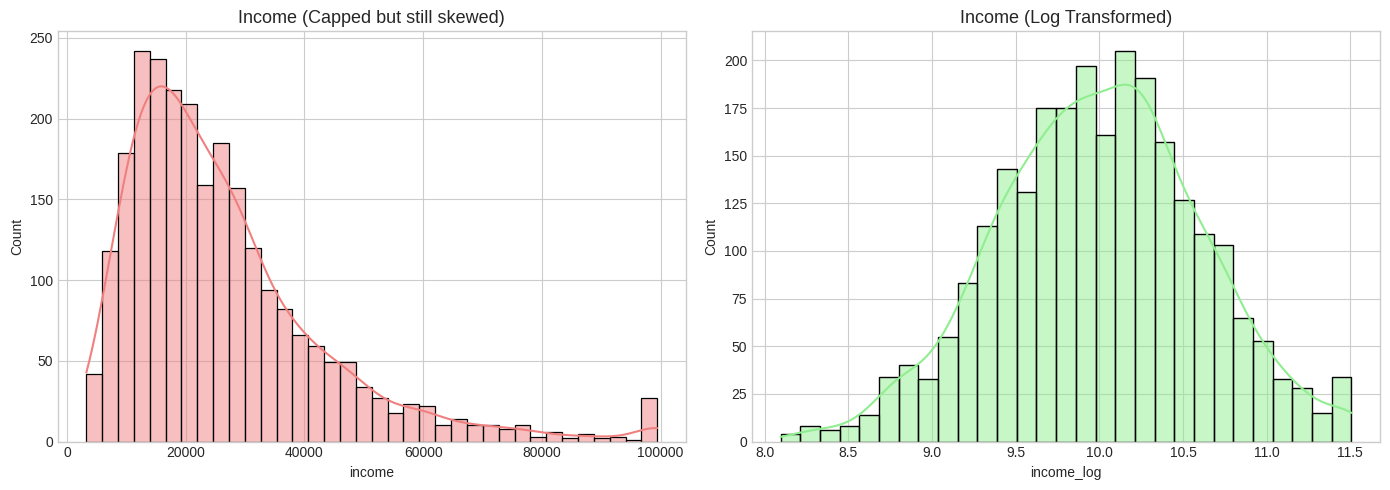

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# skewed, capped version with the spike
sns.histplot(df['income'], kde=True, ax=axes[0], color='lightcoral')
axes[0].set_title("Income (Capped but still skewed)", fontsize=13)

# log-transformed version
sns.histplot(df['income_log'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title("Income (Log Transformed)", fontsize=13)

plt.tight_layout()
plt.show()

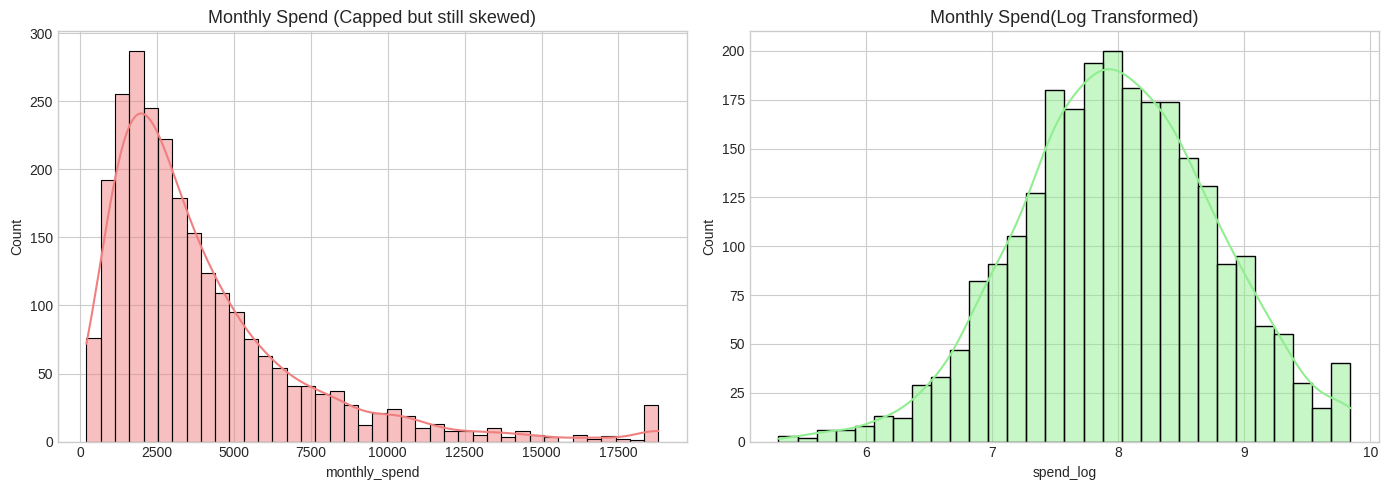

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# skewed, capped version with the spike
sns.histplot(df['monthly_spend'], kde=True, ax=axes[0], color='lightcoral')
axes[0].set_title("Monthly Spend (Capped but still skewed)", fontsize=13)

# log-transformed version
sns.histplot(df['spend_log'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title("Monthly Spend(Log Transformed)", fontsize=13)

plt.tight_layout()
plt.show()

**Why it was applied:** During EDA,income and monthly_spend identified as heavily right skewed.Even after capping extreme outliers, the distribution remained non-normal.Applying a **logrithmic transformation** compresses the long tail, resulting a more normal shaped distribution.This helps stabilize variances and improve certain machine learnign models (like logistic regression) performances that assumes normal distributed data.

### Normalization (Min-Max scaling)

In [31]:
# Performing Normalization (Min-max Scaling Technique)
scaler = MinMaxScaler()
df['credit_score_scaled'] = scaler.fit_transform(df[['credit_score']])
print("Min-Max Scaling applied to 'credit_score' -> created 'credit_score_scaled")

Min-Max Scaling applied to 'credit_score' -> created 'credit_score_scaled


**Why it was applied:** credit_score works on specific numeric scale(300-850).**Min-Max Scaling** proportionaly bound these value exactly between 0.0 to 1.0.it can never be 5000 and it can never be Negative.Min-Max scaling respect these hard limits perfectly by pinning the lowest possible score to 0.0 and highest possible score to 1.0.that's why it is the perfect scaling choice for the credit_score.

### Discretization (Binning)

In [32]:
bins = [0,35,55,100]
labels = ['Young','Middle-Aged','Senior']

df['age_group'] = pd.cut(df['age'],bins=bins,labels=labels)
print("Discretization applied to 'age' -> created 'age_group")

Discretization applied to 'age' -> created 'age_group


**Why it was applied:** Financial risk and behaviour rarely change linearly with every single birthday (e.g. 24 year old and 25 year old would probably have a similar risk profile but 25 year old and 60 year old do not).By binnig age into category ('Young','Middle-Aged','Senior'),we convert numerical variable into categorical one.

In [33]:
# Let's look at newly created features
print("\nPreview of Engineered Features:")
print(df[['income', 'income_log', 'monthly_spend','spend_log','credit_score', 'credit_score_scaled', 'age', 'age_group']].head())


Preview of Engineered Features:
         income  income_log  monthly_spend  spend_log  credit_score  \
0  31019.390823   10.342400    1732.298149   7.457781    650.336822   
1  39375.961557   10.580936    2334.610693   7.756029    648.261012   
2  18055.668704    9.801270    1848.435993   7.522636    554.304978   
3  15254.929250    9.632724    3256.259548   8.088641    656.893687   
4  11486.292927    9.348997    7767.804367   8.957872    731.298036   

   credit_score_scaled        age    age_group  
0             0.495126  43.960570  Middle-Aged  
1             0.489877  36.340828  Middle-Aged  
2             0.252297  45.772262  Middle-Aged  
3             0.511706  56.276358       Senior  
4             0.699847  35.190160  Middle-Aged  


##  Feature Construction

In [34]:
# first feature: Loan to income ratio
# Classic banking metric High Ratio = High Risk
df['loan_to_income_ratio'] = df['loan_amount'] / df['income']
print("Constructed 'loan_to_income_ratio'")

Constructed 'loan_to_income_ratio'


**Reasoning:** In the banking domain,the raw laon_amount is less important than the borrower's ability to pay it back.A 20,000 dollars loan is trivia for someone like who has monthly income of 150,000 dollars,but it is highly risky for someone with $ 25,000.By dividing loan_amount by income,we create a ratio feature that directly measures affordability and debt burden.

In [35]:
# Second feature: Spend to income ratio
# multiply monthly_spend by 12 to annualize it
df['spend_to_income_ratio'] = (df['monthly_spend']*12) / df['income']
print("Constructed 'spend_to_income_ratio'")

Constructed 'spend_to_income_ratio'


**Reasoning:** A borrower might have a high income but if their monthly spending consumes 90% of its income then they are at high risk of defaulting the loan.By Calculating the annualized spending as the fraction of total income, we capture the borrower's cash flow tightness and financial discipline.

In [36]:
# Third Feature: Risk adjusted capacity (Interaction Feature)
# Multiplying to scores together amplifying the signal of good vs bad borrower
df['risk_adjusted_capacity'] = df['financial_capacity_index'] * df['behavior_score']
print("Constructed 'risk_adjusted_capacity'")

Constructed 'risk_adjusted_capacity'


**Reasoning:** This is an interaction feature. By multiplying the financial_capacity_index (Financial indicator representing the applicant’s overall financial capacity.) by the behavior_score ( indicator representing general spending or financial behavior patterns.), we create a compound metric. This mathematically amplifies the signal of ideal borrowers (high capacity AND good behavior) while penalizing risky borrowers (low capacity AND poor behavior).

In [37]:
# Let's look at the statistics of our new features
print("\nSummary statistics of new constructed features:")
print(df[['loan_to_income_ratio', 'spend_to_income_ratio', 'risk_adjusted_capacity']].describe().round(3))


Summary statistics of new constructed features:
       loan_to_income_ratio  spend_to_income_ratio  risk_adjusted_capacity
count              2500.000               2500.000                2500.000
mean                  1.103                  2.637                1303.575
std                   0.894                  3.312                 914.037
min                   0.015                  0.038                 135.880
25%                   0.507                  0.832                 694.379
50%                   0.857                  1.654                1081.858
75%                   1.391                  3.155                1645.088
max                   7.612                 39.230               11184.338


## Categorical Feature Encoding

In [38]:
categorical_cols

['employment_type', 'education_level', 'region', 'risk_tolerance']

so we originally have 4 categorical features and after numerical feature engineering now have age_group as categorical feature.in this step we are going to do appropriate encoding on these features,

In [39]:
df['education_level'].unique()

<StringArray>
['bachelor', 'master', 'high_school', 'phd']
Length: 4, dtype: str

### Ordinal Encoding

In [40]:
# Ordinal Encoding (Mapping text to ordered numbers)
# define the exact dictionary so model learns the correct hierarchy.
edu_map = {'high_school':1,'bachelor':2,'master':3,'phd':4}
df['education_level_encoded'] = df['education_level'].map(edu_map)

# Encoding for risk_tolerance (low,medium and high)
risk_map = {'low':1,'medium':2,'high':3}
df['risk_tolerance_encoded'] = df['risk_tolerance'].map(risk_map)

# Encoding for age_group where categories are Young,Middle-Aged and Senior
age_map = {'Young': 1, 'Middle-Aged': 2, 'Senior': 3}
df['age_group_encoded'] = df['age_group'].map(age_map)

print("Applied Ordinal encoding to 'education_level','risk_tolerance','age_group'\n")

Applied Ordinal encoding to 'education_level','risk_tolerance','age_group'



**Appropriateness:** 'education_level','risk_tolerance' and 'age_group' these Features contains natural order or logical hierarchy(e.g. P.Hd represents higher education than bachelor or high risk is strictly greater than low risk).Ordinal encoding chosen because assigning them order interger(1,2,3,4) preserve their mathematicaly natural ranking,allowing machine learning model to understand their sequential relationship between the categories.

In [41]:
# One-Hot Encoding(creating binary columns for nominal data)
df = pd.get_dummies(df,columns=['employment_type','region'],drop_first=True,dtype=int)
print("Applied One-Hot encoding to 'employment_type','region'\n")

Applied One-Hot encoding to 'employment_type','region'



**Appropriateness:** 'employment_type' and 'region' Features are nominal means they don't have any mathematically ranking or order(e.g. 'north' region is not greater than 'south' region). Assigning them with Label Encoding here,algorithm falsely assume mathematical ranking or order exists. One-Hot Encoding would be practically useful here by creating separate binary (0 and 1) columns for each category.

In [42]:
# Drop the original text columns for the ordinal variables to clean up the dataset
df = df.drop(columns=['education_level', 'risk_tolerance', 'age_group'])

In [43]:
df.columns

Index(['age', 'income', 'credit_score', 'loan_amount', 'monthly_spend',
       'experience_years', 'financial_capacity_index',
       'household_cashflow_score', 'behavior_score', 'loan_default',
       'income_log', 'spend_log', 'credit_score_scaled',
       'loan_to_income_ratio', 'spend_to_income_ratio',
       'risk_adjusted_capacity', 'education_level_encoded',
       'risk_tolerance_encoded', 'age_group_encoded',
       'employment_type_self_employed', 'employment_type_student',
       'employment_type_unemployed', 'region_north', 'region_south',
       'region_west'],
      dtype='str')

**Note:** When applying One-Hot Enconding **drop_first=True** was used.This intentionally drop the first alphabatical category for each feature(e.g. 'region_east' and 'employment_type_salaried') to serve as the reference or the baseline category.This is a standard best practice to prevent **perfect multicollinearity** (the dummy variable trap) in subsequent predictive modeling.

In [44]:
# Let's verify the final state of our dataset
print("Dataset shape after encoding:", df.shape)
print("\nPreview of encoded columns:")
# Showing a mix of the new ordinal and one-hot columns
print(df[['education_level_encoded', 'risk_tolerance_encoded','region_north']].head())

Dataset shape after encoding: (2500, 25)

Preview of encoded columns:
   education_level_encoded  risk_tolerance_encoded  region_north
0                        2                       3             0
1                        2                       3             1
2                        2                       1             0
3                        3                       1             0
4                        3                       1             0


## Feature Selection

In [45]:
# Prepare our features X and target y
# We drop the target 'loan_default' from the data
X = df.drop(columns = ['loan_default'])
y = df['loan_default']

In [46]:
print("Running Feature Selection Tests...\n")

# Method 1: Pearson Correlation
# calculate correlation of  all features specifically against target variable 
# use abs() because a strong negative correlation as important as postive one
pearson_corr = X.corrwith(y).abs().sort_values(ascending=False)

Running Feature Selection Tests...



Used **corrwith()** because instead of calculating NxN matrix(in corr() method ),just take these features and correlate them only with the single target variable.it only does Nx1 Calculations.

In [47]:
# Method 2: Mutual Information
# MI can handle both linear and non-linear relationships
mi_scores = mutual_info_classif(X,y,random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

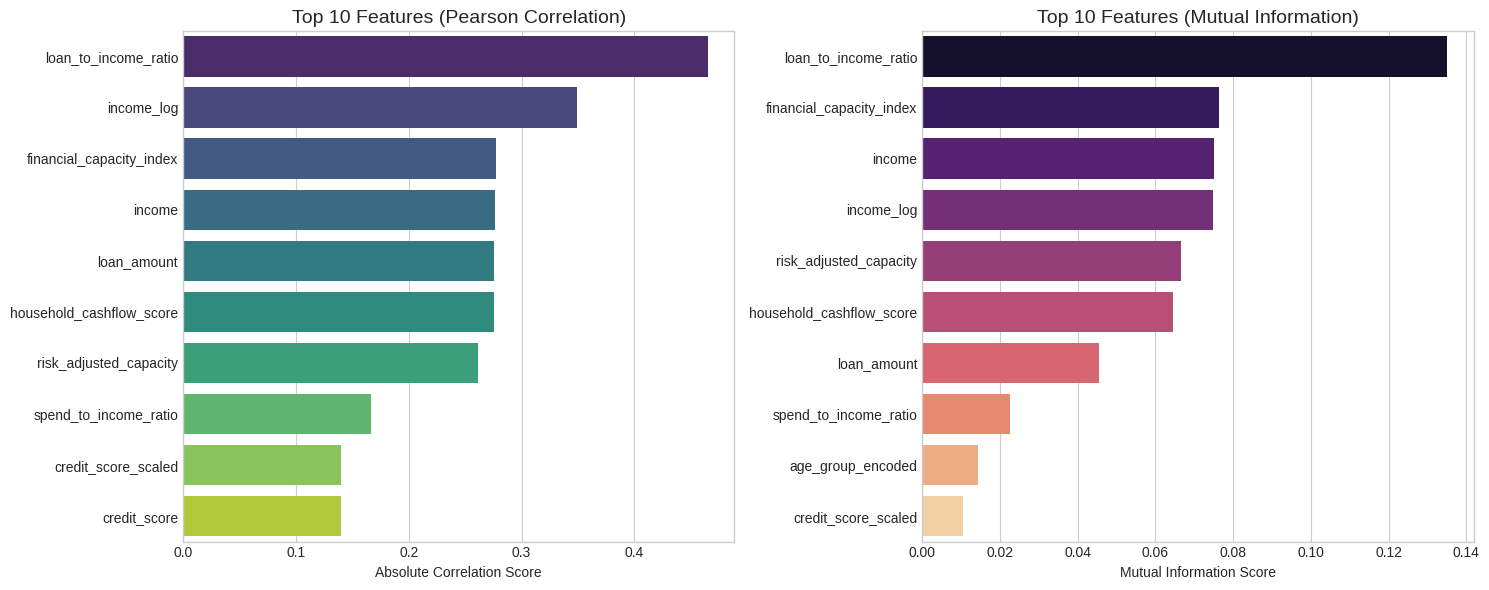

In [48]:
# Visualizing the Results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Pearson Correlation
sns.barplot(x=pearson_corr.values[:10], y=pearson_corr.index[:10], ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Features (Pearson Correlation)', fontsize=14)
axes[0].set_xlabel('Absolute Correlation Score')
axes[0].set_ylabel(None)

# Plot 2: Mutual Information
sns.barplot(x=mi_scores_series.values[:10], y=mi_scores_series.index[:10], ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Features (Mutual Information)', fontsize=14)
axes[1].set_xlabel('Mutual Information Score')
axes[1].set_ylabel(None)

plt.tight_layout()
plt.show()

**Explanations**

**1. Reasoning behind the chosen techniques** 
* **Pearson correlation** was selected to evaluate strict linear dependancy between each Feature and target variable 'loan_default'
* **Mutual Information** was selected because it relies on entropy rather than variance.Unlike pearson, MI can capture complex linear and non-linear relationship between the feature and the target variable and selecting the feature with highest information gain.It is highly robust for evaluating our constructed interaction features and categorical encodings.

**2. Which features appear most predictive** 
* Based on both selection methods,our newly constructed features(such as 'loan_to_income_ratio' and 'risk_adjusted_capacity')consistantly ranks at the top of features importance alongside 'financial_capacity_index'.This strongly validates feature engineering efforts. 


**3. Which features appear most redundant**
* During feature selection, financial_capacity_index and household_cashflow_score both showed similar predictive importance. Because from EDA that they have a 0.96 correlation with each other, they are highly redundant,they are providing the exact same predictive signal to the model.

## Multicollinearity Analysis

In [49]:
df.shape

(2500, 25)

### Variance Inflation Factor(VIF)

In [50]:
print("Running VIF Analysis...\n")

# 1. Select only numeric columns and drop the target
X_num = df.select_dtypes(include=[np.number]).drop(columns=['loan_default'], errors='ignore')

# 2. Statsmodels mathematically requires a "constant" (intercept) column to calculate VIF correctly
X_vif = add_constant(X_num)

# 3. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# 4. Display the results (excluding the constant)
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF_Score", ascending=False)
print(vif_data.round(2))

Running VIF Analysis...

                          Feature  VIF_Score
3                    credit_score        inf
12            credit_score_scaled        inf
7        financial_capacity_index      49.99
15         risk_adjusted_capacity      33.94
10                     income_log      24.61
2                          income      15.92
8        household_cashflow_score      13.53
13           loan_to_income_ratio       7.75
5                   monthly_spend       6.87
11                      spend_log       4.68
14          spend_to_income_ratio       4.38
9                  behavior_score       3.77
4                     loan_amount       2.90
21                   region_north       1.48
22                   region_south       1.47
23                    region_west       1.45
18  employment_type_self_employed       1.09
20     employment_type_unemployed       1.08
19        employment_type_student       1.06
6                experience_years       1.01
16        education_level_enco

In [51]:
# 1. Drop the raw "parent" columns and the known redundant feature
columns_to_drop = [
    'credit_score',               # Keep 'credit_score_scaled' instead
    'income',                     # Keep 'income_log' instead
    'household_cashflow_score',    # Highly correlated with financial_capacity_index
    'monthly_spend',              # We keep 'spend_to_income_ratio'
]

# Only drop them if they still exist in the dataframe
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
print(f"Successfully dropped: {columns_to_drop}\n")

# 2. Prepare data for VIF
X_num = df.select_dtypes(include=[np.number]).drop(columns=['loan_default'], errors='ignore')
X_vif = add_constant(X_num)

# 3. Recalculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# 4. Display the healed results
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF_Score", ascending=False)
print("--- NEW VIF SCORES ---")
print(vif_data.round(2))

Successfully dropped: ['credit_score', 'income', 'household_cashflow_score', 'monthly_spend']

--- NEW VIF SCORES ---
                          Feature  VIF_Score
4        financial_capacity_index      34.90
11         risk_adjusted_capacity      33.94
6                      income_log      11.64
9            loan_to_income_ratio       6.16
5                  behavior_score       3.77
10          spend_to_income_ratio       2.86
2                     loan_amount       2.49
7                       spend_log       2.04
17                   region_north       1.47
18                   region_south       1.46
19                    region_west       1.45
14  employment_type_self_employed       1.09
16     employment_type_unemployed       1.08
15        employment_type_student       1.06
3                experience_years       1.01
8             credit_score_scaled       1.01
12        education_level_encoded       1.01
13         risk_tolerance_encoded       1.01
1                          

**Analysis & Justification:**

**1. Methodology Used: Variance Inflation Factor (VIF)**
To evaluate multicollinearity,Variance Inflation factor(VIF)analysis was used.VIF measures how much the variance of the independent variable inflated due to its interaction with all other independent variables combined.

**2. Identification and Handling of Pure Redundancy**
* **Dropped:** household_cashflow_score
* **Retained:** financial_capacity_index
* **Justification:** Early EDA incdicated a near perfect correlation (0.96) between these features. In financial domain logic,financial capacity is broader,more better metric for structural loan risk than month-to-month "cashflow".Therefore "household_cashflow_score" was completely dropped to eliminate the pure redundancy,while financial_capacity_index was retained.

**3. Handling "Parent-Child" Multicollinearity**

The VIF Analysis flagged high multicollinearity(VIF>10)between our newly engineered interaction feature(e.g., risk_adjusted_capacity, loan_to_income_ratio) and their original "parent" features (e.g., financial_capacity_index, loan_amount, income_log).
* **Decision:** I explicitly chose not to drop the parent features to artificially lower the VIF scores.
* **Justification:** in feature selection step,proved that features like 'financial_capacity_index' and 'income_log' carry massive predictive power. Dropping them would severely degrade the model's accuracy.In the Dimensionality Reduction step,we will retain these highly predictive, correlated features and allow Principal Component Analysis (PCA) to mathematically compress them into completely independent, orthogonal components, effectively solving the multicollinearity without sacrificing data quality.

## Dimensionality Reduction

### Principal Component Analysis (PCA)

In [52]:
print("Applying Principal Component Analysis (PCA)...\n")

# 1. Prepare the data for PCA
# Drop the target variable (we only compress the features, never the answers!)
X = df.drop(columns=['loan_default'])

# PCA mathematically requires all features to be perfectly standardized (mean=0, variance=1)
# This ensures a feature with large numbers (like loan_amount) doesn't unfairly dominate the PCA math
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

# 2. Fit PCA to see the variance curve across all features
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate the cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
print(f"{cumulative_variance}\n")

# 3. Determine how many components are needed to keep 95% of the information
target_variance = 0.95
num_components = np.argmax(cumulative_variance >= target_variance) + 1

print(f"Original number of features: {X.shape[1]}")
print(f"Number of PCA components to retain {target_variance*100}% of variance: {num_components}\n")

# 4. Apply the final PCA with the optimal number of components
pca_final = PCA(n_components=num_components)
X_pca = pca_final.fit_transform(X_scaled)

# Create a final dataframe of our reduced, mathematically independent features
pca_columns = [f"PC{i}" for i in range(1, num_components + 1)]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

print("Shape of final reduced dataset:", df_pca.shape)

Applying Principal Component Analysis (PCA)...

[0.17902381 0.27384856 0.34813283 0.4149594  0.48129037 0.54363529
 0.60415713 0.66074334 0.71334596 0.7650593  0.8144377  0.86351367
 0.91032908 0.94309543 0.96420451 0.98162333 0.99065451 0.99649367
 0.99927804 1.        ]

Original number of features: 20
Number of PCA components to retain 95.0% of variance: 15

Shape of final reduced dataset: (2500, 15)


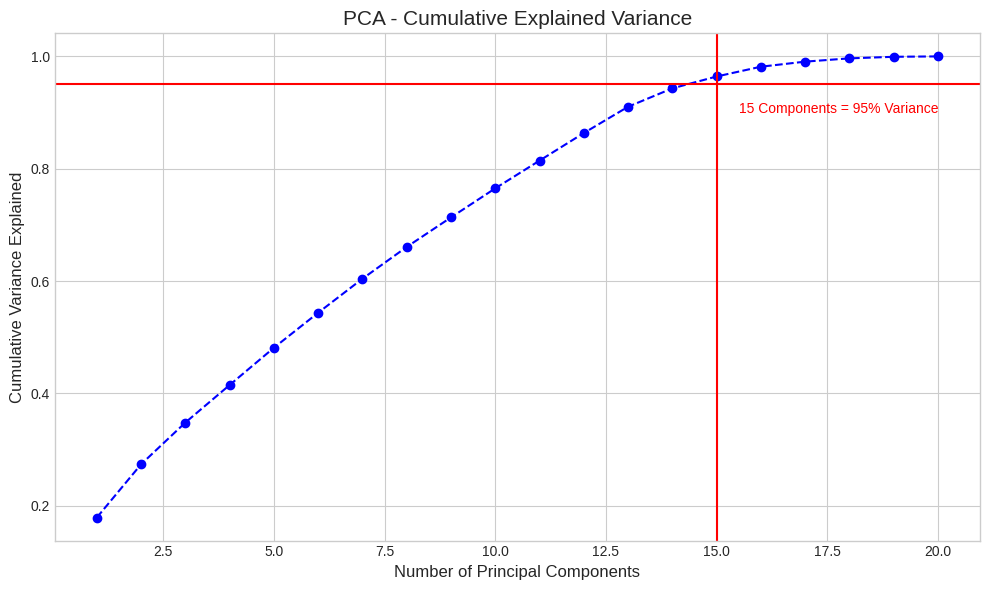

In [53]:
# Visualizing the Variance Preserved
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')

# Draw lines to show our 95% cutoff
plt.axhline(y=target_variance, color='r', linestyle='-')
plt.axvline(x=num_components, color='r', linestyle='-')

plt.title('PCA - Cumulative Explained Variance', fontsize=15)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained', fontsize=12)
plt.text(num_components + 0.5, target_variance - 0.05, f"{num_components} Components = 95% Variance", color='red')
plt.grid(True)
plt.tight_layout()
plt.show()

**Principal Component Analysis Justification:**

**why the technique was chosen:** Principal component analysis was chosen because it is the most robust method for reducing the dimensionality of the continuous data. Crucially, because highly predictive but correlated "parent" features (such as financial_capacity_index and income_log) were intentionally retained during last step, applying PCA solves multicollinearity problem entirely.PCA transform the correlated data into new,completely independent(orthogonal) principal components,ensuring the final machine learning model receives stable, non-redundant inputs.

**How many components were retained:** After analyzing the cumulative explained variance, 15 principal components retained out of 20 encoded features.This successfully compressed the width and computational complexity of the dataset by 25%.

**What information was preserved:** By selecting 15 components,95% of the original variance(the statistical information and predictive signal)of the dataset was mathematically preserved.The remaining 5% of variance—which is largely considered statistical "noise"—was intentionally discarded to achieve a lighter, faster, and strictly independent feature space.

### Exporting the Cleaned Dataset

In [54]:
# Final file Name
output_filename = "Final_Engineered_Loan_Data_PCA.csv"

# Export the dataframe to a CSV file
# use index=False so pandas doesn't save the arbitrary row numbers as a new column
df_pca.to_csv(output_filename, index=False)

print(f"Success! fully engineered dataset has been saved as: '{output_filename}'")
print(f"Final dataset shape: {df_pca.shape}")

Success! fully engineered dataset has been saved as: 'Final_Engineered_Loan_Data_PCA.csv'
Final dataset shape: (2500, 15)
